In [34]:
# WEEK 1
# importing necessary libraries & setting up th environment
import torch
import numpy as np
import matplotlib.pyplot as plt


In [35]:
# importing dataset
from datasets import load_dataset
data = load_dataset(
    "MultimodalUniverse/legacysurvey",
    split="train",
    streaming=True
)

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

In [36]:
print(data)

IterableDataset({
    features: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'],
    num_shards: 165
})


In [37]:
# Dataset Exploration

# extracting sample from datset
sample = next(iter(data))

# printing dataset & number of fields
print(data)
print("\nNumber of fields:", len(sample))
print("\nAvailable fields:")
for key in sample.keys():
    print(" -", key)

IterableDataset({
    features: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'],
    num_shards: 165
})

Number of fields: 18

Available fields:
 - image
 - blobmodel
 - rgb
 - object_mask
 - catalog
 - EBV
 - FLUX_G
 - FLUX_R
 - FLUX_I
 - FLUX_Z
 - FLUX_W1
 - FLUX_W2
 - FLUX_W3
 - FLUX_W4
 - SHAPE_R
 - SHAPE_E1
 - SHAPE_E2
 - object_id


In [38]:
# inspecting every field
print("\nField Information\n")
for key, value in sample.items():
    print(f"\n--- {key} ---")
    print("Type:", type(value))
    if hasattr(value, "shape"):
        print("Shape:", value.shape)
    if hasattr(value, "dtype"):
        print("Dtype:", value.dtype)


Field Information


--- image ---
Type: <class 'dict'>

--- blobmodel ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>

--- rgb ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>

--- object_mask ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>

--- catalog ---
Type: <class 'dict'>

--- EBV ---
Type: <class 'float'>

--- FLUX_G ---
Type: <class 'float'>

--- FLUX_R ---
Type: <class 'float'>

--- FLUX_I ---
Type: <class 'float'>

--- FLUX_Z ---
Type: <class 'float'>

--- FLUX_W1 ---
Type: <class 'float'>

--- FLUX_W2 ---
Type: <class 'float'>

--- FLUX_W3 ---
Type: <class 'float'>

--- FLUX_W4 ---
Type: <class 'float'>

--- SHAPE_R ---
Type: <class 'float'>

--- SHAPE_E1 ---
Type: <class 'float'>

--- SHAPE_E2 ---
Type: <class 'float'>

--- object_id ---
Type: <class 'str'>


In [39]:
# taking a sample imagse and inspecting the  mainimage
print("\nImage Information\n")
image = sample["image"]
print("Image type:", type(image))
print("Image:", image)
if hasattr(image, "shape"):
    print("Image shape:", image.shape)
if hasattr(image, "dtype"):
    print("Image dtype:", image.dtype)


Image Information

Image type: <class 'dict'>
Image: {'band': ['des-g', 'des-r', 'des-i', 'des-z'], 'flux': [[[0.0007380799506790936, -0.00016050622798502445, 0.0003010692889802158, 0.0009010408539324999, -0.0005762063665315509, -0.002971604699268937, 0.0027692108415067196, 0.0013593563344329596, -0.001967120449990034, -0.0016669273609295487, -0.0008193973917514086, 0.00151748675853014, 0.00043023674516007304, 0.0005182579625397921, 0.002291673794388771, -0.0011070449836552143, -0.0017752716084942222, 0.0026381714269518852, 0.0010797434952110052, -0.0020202258601784706, -0.001806977204978466, 0.000562246423214674, 0.0005059128161519766, -0.001393625745549798, -0.0007378564914688468, -2.5792658561840653e-05, 0.0003319118986837566, 0.0015727252466604114, -0.001676557818427682, 0.00042274227598682046, -0.001041117124259472, -0.0007270867936313152, 0.0012817319948226213, -0.001600002753548324, 0.0003819463890977204, -0.0035971947945654392, 0.0014767233515158296, -0.0010808437364175916, 0.

In [40]:
# inspecting the optical bands
print("\nOptical Bands\n")
bands = ["FLUX_G", "FLUX_R", "FLUX_I", "FLUX_Z"]

for band in bands:
    value = sample[band]
    print(f"\n{band}")
    print("Type:", type(value))
    print("Value:", value)
    if hasattr(value, "shape"):
        print("Shape:", value.shape)
    if hasattr(value, "dtype"):
        print("Dtype:", value.dtype)


Optical Bands


FLUX_G
Type: <class 'float'>
Value: 1.3640868663787842

FLUX_R
Type: <class 'float'>
Value: 2.831369161605835

FLUX_I
Type: <class 'float'>
Value: 4.151123523712158

FLUX_Z
Type: <class 'float'>
Value: 4.814830780029297


In [41]:
# Inspecting important metadata
print("\nGalaxy Metadata\n")
metadata_fields = [
    "object_id",
    "EBV",
    "SHAPE_R",
    "SHAPE_E1",
    "SHAPE_E2"
]
for field in metadata_fields:
    value = sample[field]
    print(f"\n{field}")
    print("Type:", type(value))
    print("Value:", value)


Galaxy Metadata


object_id
Type: <class 'str'>
Value: b'0421p022-7410'

EBV
Type: <class 'float'>
Value: 0.06657393276691437

SHAPE_R
Type: <class 'float'>
Value: 0.9420995116233826

SHAPE_E1
Type: <class 'float'>
Value: 0.23311986029148102

SHAPE_E2
Type: <class 'float'>
Value: -0.33112043142318726


In [42]:
# Inspecting RGB, mask and catalog
print("\nOther Important Fields")
for field in ["rgb", "object_mask", "catalog", "blobmodel"]:
    value = sample[field]
    print(f"\n--- {field} ---")
    print("Type:", type(value))
    if hasattr(value, "shape"):
        print("Shape:", value.shape)
    if hasattr(value, "dtype"):
        print("Dtype:", value.dtype)


Other Important Fields

--- rgb ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>

--- object_mask ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>

--- catalog ---
Type: <class 'dict'>

--- blobmodel ---
Type: <class 'PIL.PngImagePlugin.PngImageFile'>


Bands: ['des-g', 'des-r', 'des-i', 'des-z']
Flux shape: (4, 160, 160)


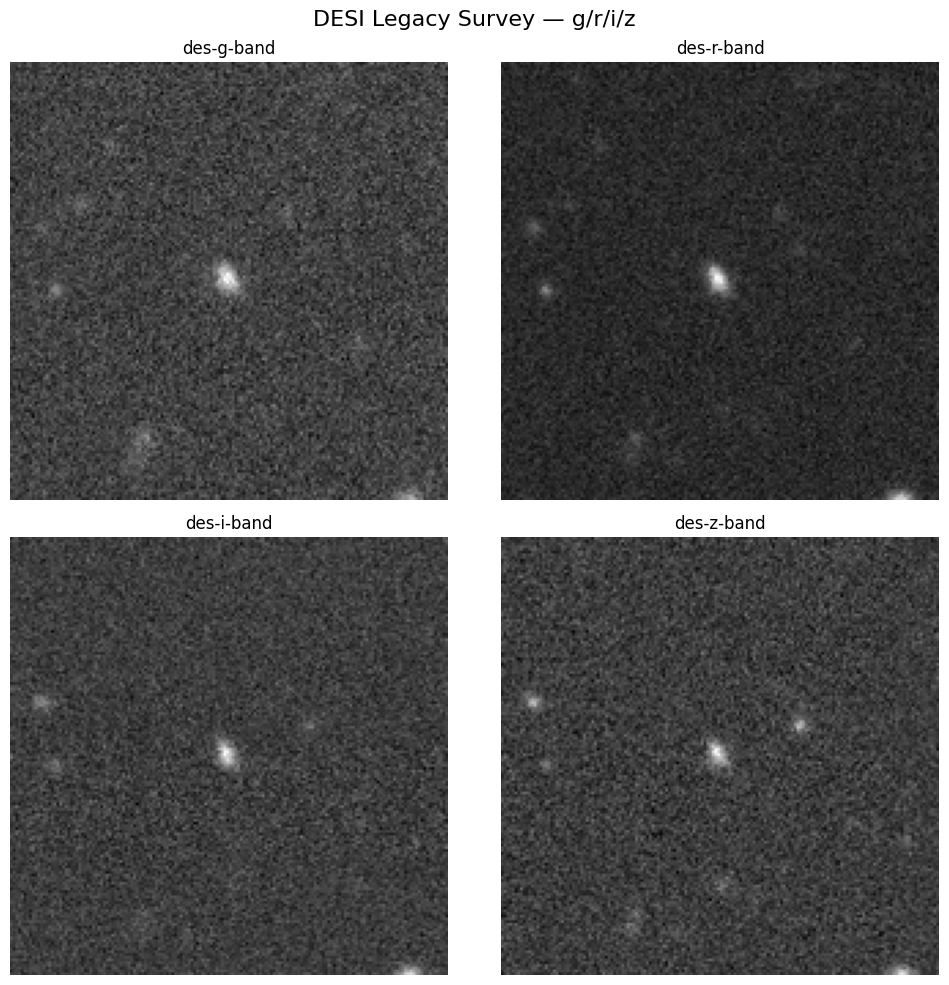

In [50]:
# Griz Visualization
image_data = sample["image"]

# Convert flux data to array
flux = np.array(image_data["flux"])

# Get band names
bands = image_data["band"]

print("Bands:", bands)
print("Flux shape:", flux.shape)

# Create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, band_name, band_image in zip(
    axes.ravel(),
    bands,
    flux
):
    ax.imshow(band_image, cmap="gray")
    ax.set_title(f"{band_name}-band")
    ax.axis("off")

plt.suptitle("DESI Legacy Survey — g/r/i/z", fontsize=16)
plt.tight_layout()
plt.show()

In [51]:
# Loading pretrained DINOv2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)
dinov2 = dinov2.to(device)
dinov2.eval()

Using device: cpu
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 238MB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [52]:
# Image Preprocessing
# inspecting rgb image

rgb_image = sample["rgb"]
print("Original image type:", type(rgb_image))
print("Original image size:", rgb_image.size)
print("Original image mode:", rgb_image.mode)

# Defining DINOv2 preprocessing

from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Original image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Original image size: (160, 160)
Original image mode: RGB


In [53]:
# Apply preprocessing
input_image = transform(rgb_image)

# Inspecting the resulting tensor
print("\nPreprocessed image:")
print("Type:", type(input_image))
print("Shape:", input_image.shape)
print("Dtype:", input_image.dtype)


Preprocessed image:
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Dtype: torch.float32


In [54]:
# Adding batch dimension
input_image = input_image.unsqueeze(0)
print("\nAfter adding batch dimension:")
print("Shape:", input_image.shape)

# Moving image to the same device as DINOv2
input_image = input_image.to(device)
print("Final device:", input_image.device)


After adding batch dimension:
Shape: torch.Size([1, 3, 224, 224])
Final device: cpu


In [55]:
# Running DINOv2 Inference

# setting model in evaluation mode
dinov2.eval()

# Disable gradient calculation
with torch.no_grad():
    # Passing the image
    output = dinov2(input_image)

# Inspecting the output
print("Output type:", type(output))
print("Output shape:", output.shape)

Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 384])


In [57]:
# Extracting CLS token
dinov2.eval()

# Extracting internal features from DINOv2
with torch.no_grad():
    features = dinov2.forward_features(input_image)

# Extracting the normalized CLS token
cls_token = features["x_norm_clstoken"]

# Printing the result
print("CLS token type:", type(cls_token))
print("CLS token shape:", cls_token.shape)
print("CLS token device:", cls_token.device)

CLS token type: tensor([[-1.8138e+00,  1.9696e-01,  5.0432e-01, -6.3986e-01,  1.2943e+00,
          1.1657e+00,  5.1284e+00, -2.3944e+00, -4.8724e+00,  2.0453e+00,
          2.0206e+00, -5.2330e-01, -2.4908e+00, -2.1303e+00,  6.8543e-01,
          4.0538e+00, -3.2510e-01,  4.9996e-02, -4.9351e+00,  2.1751e+00,
         -4.8522e-01,  9.0531e-01, -5.0863e-01, -1.1545e+00, -1.2866e+00,
         -1.1408e+00,  5.4503e-01,  5.7291e-01,  9.6980e-01, -6.4510e-01,
          2.5192e+00,  1.8030e+00, -3.8419e+00,  1.7825e+00,  1.6875e-01,
          2.0335e+00, -2.0447e+00, -3.2368e+00, -3.7307e+00, -1.8005e+00,
          2.7341e+00, -1.8971e+00, -3.0778e+00,  1.6580e+00, -3.9912e-01,
         -1.4360e+00,  1.3985e-01, -1.1111e+00, -6.3053e-01,  3.1827e+00,
         -1.2030e+00,  5.3359e-01,  7.2752e-01,  8.6149e-01,  1.4027e+00,
         -1.1205e+00, -1.0248e+00, -8.9062e-01,  2.2648e-01, -3.4138e+00,
         -1.7774e+00, -2.4278e-01, -3.7247e+00,  2.4334e+00, -3.1661e+00,
         -6.2766e-02, 

In [58]:
# Extracting patch tokens
patch_tokens = features["x_norm_patchtokens"]
print("Patch tokens type:", type(patch_tokens))
print("Patch tokens shape:", patch_tokens.shape)
print("Patch tokens device:", patch_tokens.device)

Patch tokens type: <class 'torch.Tensor'>
Patch tokens shape: torch.Size([1, 256, 384])
Patch tokens device: cpu


In [59]:
# Inspecting feature dimensions

print("CLS token shape:")
print(cls_token.shape)
print("\nPatch tokens shape:")
print(patch_tokens.shape)
print("\nNumber of images:", patch_tokens.shape[0])
print("Number of patches:", patch_tokens.shape[1])
print("Embedding dimension:", patch_tokens.shape[2])

# Calculate patch grid
num_patches = patch_tokens.shape[1]
grid_size = int(num_patches ** 0.5)
print("\nPatch grid:", grid_size, "x", grid_size)
print("Total patches:", grid_size * grid_size)

CLS token shape:
torch.Size([1, 384])

Patch tokens shape:
torch.Size([1, 256, 384])

Number of images: 1
Number of patches: 256
Embedding dimension: 384

Patch grid: 16 x 16
Total patches: 256


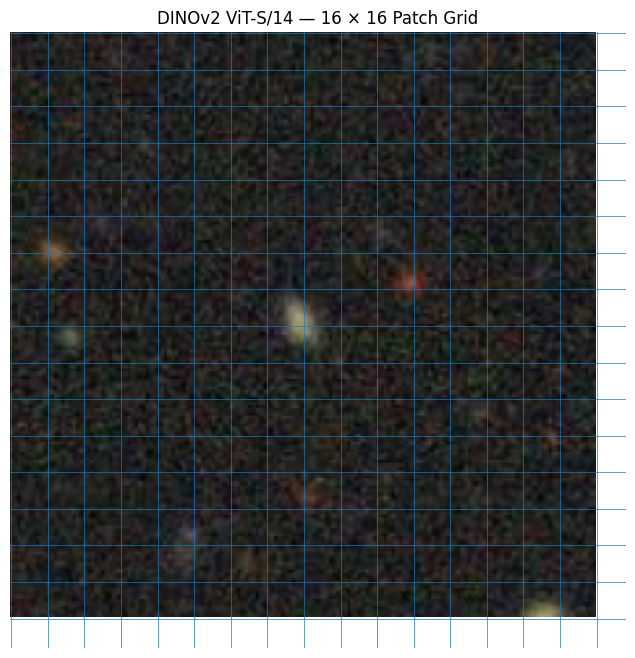

In [60]:
# Visualizing path grid

# Display the original preprocessed image
image_to_show = input_image[0].cpu().permute(1, 2, 0).numpy()

# Undo ImageNet normalization for visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_to_show = image_to_show * std + mean
image_to_show = np.clip(image_to_show, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(image_to_show)

# Drawing the boundaires
patch_size = 14

for i in range(0, 225, patch_size):
    plt.axhline(i, linewidth=0.5)
    plt.axvline(i, linewidth=0.5)

plt.title("DINOv2 ViT-S/14 — 16 × 16 Patch Grid")
plt.axis("off")
plt.show()

In [61]:
# Initial Embedding exporation

print("CLS token:")
print(cls_token)

print("\nFirst patch token:")
print(patch_tokens[0, 0])

print("\n--------------------------------")

print("CLS token statistics:")
print("Minimum:", cls_token.min().item())
print("Maximum:", cls_token.max().item())
print("Mean:", cls_token.mean().item())
print("Standard deviation:", cls_token.std().item())

print("\nPatch token statistics:")
print("Minimum:", patch_tokens.min().item())
print("Maximum:", patch_tokens.max().item())
print("Mean:", patch_tokens.mean().item())
print("Standard deviation:", patch_tokens.std().item())

CLS token:
tensor([[-1.8138e+00,  1.9696e-01,  5.0432e-01, -6.3986e-01,  1.2943e+00,
          1.1657e+00,  5.1284e+00, -2.3944e+00, -4.8724e+00,  2.0453e+00,
          2.0206e+00, -5.2330e-01, -2.4908e+00, -2.1303e+00,  6.8543e-01,
          4.0538e+00, -3.2510e-01,  4.9996e-02, -4.9351e+00,  2.1751e+00,
         -4.8522e-01,  9.0531e-01, -5.0863e-01, -1.1545e+00, -1.2866e+00,
         -1.1408e+00,  5.4503e-01,  5.7291e-01,  9.6980e-01, -6.4510e-01,
          2.5192e+00,  1.8030e+00, -3.8419e+00,  1.7825e+00,  1.6875e-01,
          2.0335e+00, -2.0447e+00, -3.2368e+00, -3.7307e+00, -1.8005e+00,
          2.7341e+00, -1.8971e+00, -3.0778e+00,  1.6580e+00, -3.9912e-01,
         -1.4360e+00,  1.3985e-01, -1.1111e+00, -6.3053e-01,  3.1827e+00,
         -1.2030e+00,  5.3359e-01,  7.2752e-01,  8.6149e-01,  1.4027e+00,
         -1.1205e+00, -1.0248e+00, -8.9062e-01,  2.2648e-01, -3.4138e+00,
         -1.7774e+00, -2.4278e-01, -3.7247e+00,  2.4334e+00, -3.1661e+00,
         -6.2766e-02,  2.87